# Hybrid BPR — SBERT + Filtrado Colaborativo

Modelo de fusión temprana que combina señal semántica (SBERT) con ranking colaborativo pairwise (BPR).

**Arquitectura:**
- Los factores de ítem se inicializan desde la proyección de embeddings SBERT (384→64 con capa lineal aprendible)
- Los factores de usuario se inicializan aleatoriamente
- La función de pérdida combina BPR pairwise + regularización de contenido:
  $$\mathcal{L} = \mathcal{L}_{\text{BPR}} + \lambda \|V - \text{proj}(E_{\text{SBERT}})\|_F^2$$
  donde $V$ son los factores de ítem y $\lambda$ controla qué tanto se anclan al espacio semántico.

**Diferencia con BPR vanilla:** los factores de ítem *arrancan* con conocimiento semántico de contenido y la regularización evita que se alejen demasiado durante el entrenamiento colaborativo.

In [ ]:
!pip install -q kagglehub implicit sentence-transformers

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
from IPython.display import display
import torch
import torch.nn as nn
import implicit
import kagglehub
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Hiperparámetros ──────────────────────────────────────────────────────────
RANDOM_STATE  = 42
KS            = (5, 10, 20)
TOP_K         = max(KS)
MAX_EVAL      = 2_000
ALPHA         = 40       # confianza ALS/BPR vanilla
MIN_USER      = 5
MIN_GAME      = 20
SAMPLE_FRAC   = 0.10

# Híbrido BPR
FACTORS       = 64
LR            = 0.001
N_EPOCHS      = 50
BATCH_SIZE    = 4096
CONTENT_REG   = 0.01    # λ: 0.0 = solo warm-start, >0 = ancla semántica activa
WEIGHT_DECAY  = 1e-5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 35.3 MB/s eta 0:00:00
Device: cpu


## 1. Carga de datos y preprocesamiento

Idéntico al notebook `BPR.ipynb`: dedup → k-core → confidence → subsample 10% → split temporal leave-one-out.

In [ ]:
PATH = kagglehub.dataset_download('antonkozyriev/game-recommendations-on-steam')

chunks = []
for chunk in pd.read_csv(
    os.path.join(PATH, 'recommendations.csv'),
    chunksize=1_000_000,
    dtype={'app_id':'int32','user_id':'int32','hours':'float32',
           'is_recommended':'bool','helpful':'int16','funny':'int16'},
    parse_dates=['date']
):
    chunks.append(chunk)
recs = pd.concat(chunks, ignore_index=True)
print(f'Cargado: {len(recs):,} filas')

# Deduplicación
recs = (recs.sort_values('date')
            .drop_duplicates(subset=['user_id','app_id'], keep='last')
            .reset_index(drop=True))

# Señal de confianza
recs['confidence'] = np.where(
    recs['is_recommended'], np.log1p(recs['hours'].clip(0)), 0.0
)

# K-core iterativo
def k_core(df, min_u=MIN_USER, min_g=MIN_GAME):
    for it in range(1, 30):
        n0 = len(df)
        uc, gc = df['user_id'].value_counts(), df['app_id'].value_counts()
        df = df[
            df['user_id'].isin(uc[uc >= min_u].index) &
            df['app_id'].isin(gc[gc >= min_g].index)
        ].copy()
        print(f'  iter {it}: {n0:,} → {len(df):,}')
        if len(df) == n0: break
    return df

print('K-core...')
recs = k_core(recs)

# Subsample 10%
np.random.seed(RANDOM_STATE)
sampled = pd.Series(recs['user_id'].unique()).sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
recs = recs[recs['user_id'].isin(sampled)].copy()

# Split temporal leave-one-out
recs = recs.sort_values(['user_id','date'])
last_idx = recs.groupby('user_id').tail(1).index
train_df = recs.drop(index=last_idx).reset_index(drop=True)
test_df  = recs.loc[last_idx].reset_index(drop=True)
test_pos = test_df[test_df['is_recommended']].copy()

test_item_per_user   = dict(zip(test_pos['user_id'], test_pos['app_id']))
train_items_per_user = train_df.groupby('user_id')['app_id'].apply(set).to_dict()

print(f'Train: {len(train_df):,} | Test evaluable: {len(test_pos):,} usuarios')

100%|██████████| 660M/660M [00:09<00:00, 70.8MB/s]

Extracting files...


Cargado: 41,154,794 filas
K-core...
  iter 1: 41,154,773 → 22,339,679
  iter 2: 22,339,679 → 22,294,605
  iter 3: 22,294,605 → 22,287,486
  iter 4: 22,287,486 → 22,287,105
  iter 5: 22,287,105 → 22,287,029
  iter 6: 22,287,029 → 22,286,991
  iter 7: 22,286,991 → 22,286,979
  iter 8: 22,286,979 → 22,286,960
  iter 9: 22,286,960 → 22,286,960
Train: 2,036,135 | Test evaluable: 160,266 usuarios


In [ ]:
user_list   = sorted(train_df['user_id'].unique())
item_list   = sorted(recs['app_id'].unique())
user_to_idx = {u: i for i, u in enumerate(user_list)}
item_to_idx = {a: j for j, a in enumerate(item_list)}
n_users, n_items = len(user_list), len(item_list)

tp   = train_df[train_df['is_recommended']].copy()
tp   = tp[tp['user_id'].isin(user_to_idx) & tp['app_id'].isin(item_to_idx)]
rows = tp['user_id'].map(user_to_idx).to_numpy()
cols = tp['app_id'].map(item_to_idx).to_numpy()

popularity    = train_df[train_df['is_recommended']].groupby('app_id').size()
popular_list  = popularity.sort_values(ascending=False).index.tolist()
item_pop_dict = popularity.to_dict()

rng        = np.random.default_rng(RANDOM_STATE)
eval_users = list(test_item_per_user.keys())
if len(eval_users) > MAX_EVAL:
    eval_users = list(rng.choice(eval_users, MAX_EVAL, replace=False))

n_train_users = train_df['user_id'].nunique()
print(f'n_users={n_users:,} | n_items={n_items:,} | eval_users={len(eval_users):,}')

n_users=190,545 | n_items=22,265 | eval_users=2,000


## 2. Framework de evaluación

In [ ]:
def precision_at_k(rec, rel, k):
    return sum(1 for x in rec[:k] if x in rel) / k

def recall_at_k(rec, rel, k):
    hits = sum(1 for x in rec[:k] if x in rel)
    return hits / len(rel) if rel else 0.0

def ndcg_at_k(rec, rel, k):
    dcg  = sum(1/np.log2(i+2) for i,x in enumerate(rec[:k]) if x in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(rel), k)))
    return dcg/idcg if idcg > 0 else 0.0

def evaluate_at_ks(recs, test_dict, ks=KS):
    scores = {k: {'P':[],'R':[],'N':[]} for k in ks}
    for u, rec in recs.items():
        if u not in test_dict: continue
        rel = {test_dict[u]}
        for k in ks:
            scores[k]['P'].append(precision_at_k(rec, rel, k))
            scores[k]['R'].append(recall_at_k(rec, rel, k))
            scores[k]['N'].append(ndcg_at_k(rec, rel, k))
    result = {}
    for k in ks:
        result[f'Precision@{k}'] = float(np.mean(scores[k]['P']))
        result[f'Recall@{k}']    = float(np.mean(scores[k]['R']))
        result[f'NDCG@{k}']      = float(np.mean(scores[k]['N']))
    result['n_users'] = len(scores[ks[0]]['P'])
    return result

def coverage_at_k(recs, catalog_size, k=10):
    return len({x for items in recs.values() for x in items[:k]}) / catalog_size

def novelty_at_k(recs, pop_dict, n_train, k=10):
    scores = []
    for items in recs.values():
        scores.append(np.mean([-np.log2(pop_dict.get(i,1)/n_train+1e-10) for i in items[:k]]))
    return float(np.mean(scores)) if scores else 0.0

def ild_at_k(recs, i2idx, factors, k=10):
    f = np.array(factors, dtype='float32')
    scores = []
    for items in recs.values():
        idxs = [i2idx[i] for i in items[:k] if i in i2idx]
        if len(idxs) < 2: continue
        vecs = normalize(f[idxs])
        sim  = vecs @ vecs.T
        n    = len(idxs)
        scores.append(1.0 - float((sim.sum()-n)/(n*(n-1))))
    return float(np.mean(scores)) if scores else 0.0

def activity_ndcg(recs, test_dict, train_dict, k=10):
    bins = [(2,5,'2-5'),(6,10,'6-10'),(11,20,'11-20'),(21,9999,'21+')]
    result = {}
    for lo, hi, label in bins:
        vals = [
            ndcg_at_k(rec, {test_dict[u]}, k)
            for u, rec in recs.items()
            if u in test_dict and lo <= len(train_dict.get(u, set())) <= hi
        ]
        result[label] = (float(np.mean(vals)) if vals else 0.0, len(vals))
    return result

print('Framework listo.')

Framework listo.


## 3. Embeddings SBERT

Se codifica cada juego con `all-MiniLM-L6-v2` (384 dims) concatenando título + descripción (primeras 300 palabras) + tags (hasta 20). Los embeddings se L2-normalizan para que el dot product equivalga a similitud coseno.

In [ ]:
# Carga de metadatos
games_df  = pd.read_csv(os.path.join(PATH, 'games.csv'))
title_map = dict(zip(games_df['app_id'], games_df['title'].fillna('')))

meta = {}
with open(os.path.join(PATH, 'games_metadata.json'), encoding='utf-8') as f:
    for line in f:
        try:
            rec = json.loads(line.strip())
            meta[rec['app_id']] = rec
        except:
            pass
print(f'Metadatos cargados: {len(meta):,} juegos')

def parse_tags(x):
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return json.loads(x)
        except: return [t.strip() for t in x.split(',') if t.strip()]
    return []

# Construir texto por ítem
item_texts = []
for app_id in item_list:
    rec   = meta.get(app_id, {})
    title = title_map.get(app_id, '')
    desc  = (rec.get('description') or '')[:300]
    tags  = ' '.join(str(t) for t in parse_tags(rec.get('tags', []))[:20])
    item_texts.append(f'{title}. {desc}. {tags}'.strip())

print(f'Textos construidos para {len(item_texts):,} juegos')
print(f'Ejemplo: {item_texts[0][:120]}...')

# Codificación SBERT (~5-10 min en CPU, ~1-2 min en GPU)
sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
item_sbert  = sbert_model.encode(
    item_texts, batch_size=512, show_progress_bar=True, normalize_embeddings=True
)
item_sbert  = item_sbert.astype('float32')  # (n_items, 384)
print(f'Embeddings SBERT: {item_sbert.shape}')

# Proyección fija: SBERT 384 → 64 vía TruncatedSVD
# Ancla semántica no aprendible — evita la dependencia circular del modelo anterior
from sklearn.decomposition import TruncatedSVD
svd      = TruncatedSVD(n_components=FACTORS, random_state=RANDOM_STATE)
sbert_64 = normalize(svd.fit_transform(item_sbert)).astype('float32')
print(f'SBERT proyectado (SVD): {sbert_64.shape}  — varianza explicada: {svd.explained_variance_ratio_.sum():.1%}')

Metadatos cargados: 50,872 juegos
Textos construidos para 22,265 juegos
Ejemplo: Counter-Strike. Play the world's number 1 online action game. Engage in an incredibly realistic brand of terrorist warfa...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Embeddings SBERT: (22265, 384)
SBERT proyectado (SVD): (22265, 64)  — varianza explicada: 57.5%


## 4. BPR Vanilla (baseline de comparación)

Mismo modelo que `BPR.ipynb`, ejecutado en este notebook para que los resultados sean comparables en el mismo run (mismo sample de `eval_users`).

In [ ]:
try:
    from implicit.bpr import BayesianPersonalizedRanking
except ImportError:
    from implicit.cpu.bpr import BayesianPersonalizedRanking

user_item_bpr = csr_matrix(
    (np.ones(len(tp), dtype='float32'), (rows, cols)),
    shape=(n_users, n_items)
)

bpr_vanilla = BayesianPersonalizedRanking(
    factors=FACTORS, learning_rate=0.01, regularization=0.01,
    iterations=100, random_state=RANDOM_STATE
)
bpr_vanilla.fit(user_item_bpr, show_progress=True)

recs_bpr = {}
for u in eval_users:
    seen = train_items_per_user.get(u, set())
    if u not in user_to_idx:
        recs_bpr[u] = [i for i in popular_list if i not in seen][:TOP_K]; continue
    ui = user_to_idx[u]
    ids, _ = bpr_vanilla.recommend(
        ui, user_item_bpr[ui], N=TOP_K+len(seen), filter_already_liked_items=True
    )
    recs_bpr[u] = [item_list[j] for j in ids if item_list[j] not in seen][:TOP_K]

metrics_bpr = evaluate_at_ks(recs_bpr, test_item_per_user)
div_bpr     = {
    'Coverage@10': coverage_at_k(recs_bpr, n_items),
    'Novelty@10':  novelty_at_k(recs_bpr, item_pop_dict, n_train_users),
    'ILD@10':      ild_at_k(recs_bpr, item_to_idx, bpr_vanilla.item_factors),
}
print('BPR Vanilla')
for k in KS:
    print(f'  NDCG@{k}={metrics_bpr[f"NDCG@{k}"]:.4f}  R@{k}={metrics_bpr[f"Recall@{k}"]:.4f}')
print('  ' + '  '.join(f'{m}={v:.4f}' for m,v in div_bpr.items()))

  0%|          | 0/100 [00:00<?, ?it/s]

BPR Vanilla
  NDCG@5=0.0222  R@5=0.0335
  NDCG@10=0.0303  R@10=0.0590
  NDCG@20=0.0388  R@20=0.0920
  Coverage@10=0.1594  Novelty@10=9.1498  ILD@10=0.3961


## 5. Hybrid BPR — ancla semántica fija (SVD) + BPR

**Arquitectura:**
- `sbert_anchor`: proyección SVD de SBERT 384→64 — **fija, no aprendible**
- `item_emb`: factores de ítem inicializados desde `sbert_anchor`, actualizados por BPR + regularización
- `user_emb`: factores de usuario, inicializados aleatoriamente

**Pérdida:**
$$\mathcal{L} = \underbrace{-\log\sigma(\hat{x}_{uj} - \hat{x}_{uk})}_{\text{BPR}} + \lambda \underbrace{\|V - \text{sbert\_anchor}\|_F^2}_{\text{content reg}}$$

Al ser `sbert_anchor` un buffer fijo, no existe dependencia circular: `item_emb` se mueve hacia donde la señal colaborativa indique, mientras la regularización lo ancla al espacio semántico.

In [ ]:
class HybridBPR(nn.Module):
    def __init__(self, n_users, n_items, sbert_64, content_reg=0.01):
        super().__init__()
        factors = sbert_64.shape[1]  # 64

        # Ancla semántica fija (buffer no entrenable)
        self.register_buffer('sbert_anchor', torch.FloatTensor(sbert_64))

        # Factores de ítem: inicializados desde la proyección SVD de SBERT
        self.item_emb = nn.Embedding(n_items, factors)
        with torch.no_grad():
            self.item_emb.weight.copy_(self.sbert_anchor)

        # Factores de usuario: inicialización aleatoria
        self.user_emb = nn.Embedding(n_users, factors)
        nn.init.normal_(self.user_emb.weight, std=0.01)

        self.content_reg = content_reg

    def forward(self, u, i_pos, i_neg):
        u_vec = self.user_emb(u)
        v_pos = self.item_emb(i_pos)
        v_neg = self.item_emb(i_neg)

        diff     = (u_vec * v_pos).sum(1) - (u_vec * v_neg).sum(1)
        bpr_loss = -torch.log(torch.sigmoid(diff) + 1e-8).mean()

        if self.training and self.content_reg > 0:
            # Ancla fija: sin dependencia circular, sin colapso
            content_loss = ((self.item_emb.weight - self.sbert_anchor) ** 2).mean()
            return bpr_loss + self.content_reg * content_loss

        return bpr_loss


def train_hybrid(model, rows, cols, n_items, n_epochs, batch_size, lr,
                 weight_decay, device):
    model.to(device)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    n_pos = len(rows)

    for epoch in range(1, n_epochs + 1):
        model.train()
        perm   = np.random.permutation(n_pos)
        u_shuf = rows[perm]
        i_shuf = cols[perm]
        total_loss, n_batches = 0.0, 0

        for start in range(0, n_pos, batch_size):
            end = start + batch_size
            u_b = torch.LongTensor(u_shuf[start:end]).to(device)
            i_b = torch.LongTensor(i_shuf[start:end]).to(device)
            j_b = torch.randint(0, n_items, (len(u_b),), device=device)

            optimizer.zero_grad()
            loss = model(u_b, i_b, j_b)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}/{n_epochs} — loss: {total_loss/n_batches:.4f}')

    model.eval()
    return model


def get_recs_hybrid(model, eval_users, user_to_idx, item_list,
                    item_to_idx, train_items_per_user, popular_list, TOP_K, device):
    model.eval().to('cpu')
    item_vecs = model.item_emb.weight.detach().numpy()  # (n_items, F)

    recs = {}
    for u in eval_users:
        seen = train_items_per_user.get(u, set())
        if u not in user_to_idx:
            recs[u] = [i for i in popular_list if i not in seen][:TOP_K]; continue
        uid    = user_to_idx[u]
        u_vec  = model.user_emb.weight[uid].detach().numpy()
        scores = item_vecs @ u_vec
        for s in seen:
            if s in item_to_idx:
                scores[item_to_idx[s]] = -np.inf
        top_idxs = np.argsort(scores)[::-1][:TOP_K]
        recs[u]  = [item_list[j] for j in top_idxs]
    return recs

print('Modelo y funciones definidos.')

Modelo y funciones definidos.


## 6. Entrenamiento y evaluación

In [ ]:
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

hybrid_model = HybridBPR(
    n_users=n_users,
    n_items=n_items,
    sbert_64=sbert_64,
    content_reg=CONTENT_REG
)
print(f'Parámetros: {sum(p.numel() for p in hybrid_model.parameters()):,}')
print(f'CONTENT_REG={CONTENT_REG} — {"ancla semántica activa" if CONTENT_REG > 0 else "solo warm-start"}')

hybrid_model = train_hybrid(
    hybrid_model, rows, cols, n_items,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    lr=LR, weight_decay=WEIGHT_DECAY, device=device
)

Parámetros: 13,619,840
CONTENT_REG=0.01 — ancla semántica activa
Epoch  10/50 — loss: 0.3435
Epoch  20/50 — loss: 0.3433
Epoch  30/50 — loss: 0.3433
Epoch  40/50 — loss: 0.3428
Epoch  50/50 — loss: 0.3425


In [ ]:
recs_hybrid = get_recs_hybrid(
    hybrid_model, eval_users, user_to_idx, item_list,
    item_to_idx, train_items_per_user, popular_list, TOP_K, device
)

metrics_hybrid = evaluate_at_ks(recs_hybrid, test_item_per_user)
div_hybrid     = {
    'Coverage@10': coverage_at_k(recs_hybrid, n_items),
    'Novelty@10':  novelty_at_k(recs_hybrid, item_pop_dict, n_train_users),
    'ILD@10':      ild_at_k(recs_hybrid, item_to_idx,
                             hybrid_model.item_emb.weight.detach().numpy()),
}
print('Hybrid BPR')
for k in KS:
    print(f'  NDCG@{k}={metrics_hybrid[f"NDCG@{k}"]:.4f}  R@{k}={metrics_hybrid[f"Recall@{k}"]:.4f}')
print('  ' + '  '.join(f'{m}={v:.4f}' for m,v in div_hybrid.items()))

Hybrid BPR
  NDCG@5=0.0125  R@5=0.0220
  NDCG@10=0.0168  R@10=0.0355
  NDCG@20=0.0225  R@20=0.0585
  Coverage@10=0.0021  Novelty@10=4.7496  ILD@10=0.0001


## 7. Comparación de resultados

=== Métricas de Ranking y Diversidad ===


,P@5,R@5,NDCG@5,P@10,R@10,NDCG@10,P@20,R@20,NDCG@20,Coverage@10,Novelty@10,ILD@10
Modelo,,,,,,,,,,,,
BPR Vanilla,0.0067,0.0335,0.0222,0.0059,0.0590,0.0303,0.0046,0.0920,0.0388,0.1594,9.1498,0.3961
Hybrid BPR,0.0044,0.0220,0.0125,0.0036,0.0355,0.0168,0.0029,0.0585,0.0225,0.0021,4.7496,0.0001


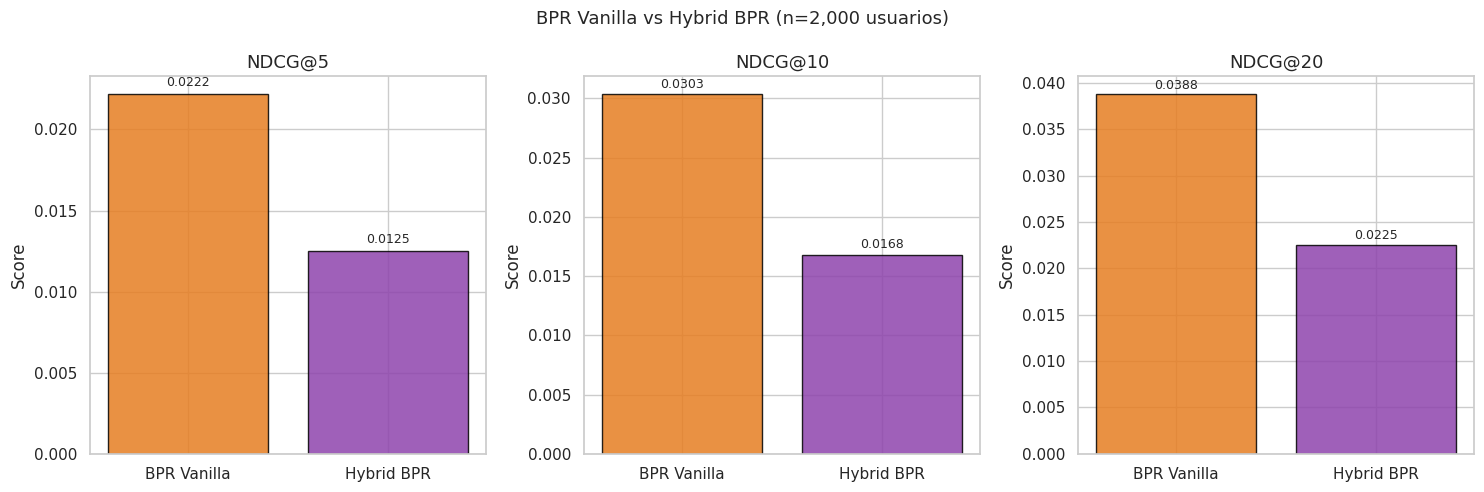


=== NDCG@10 por nivel de actividad ===
N usuarios por grupo: {'2-5': 746, '6-10': 726, '11-20': 353, '21+': 175}


,2-5,6-10,11-20,21+
BPR Vanilla,0.0405,0.0238,0.0249,0.0252
Hybrid BPR,0.0216,0.0166,0.0097,0.0116



Mejora de NDCG@10 relativa a BPR Vanilla:
  BPR Vanilla    : 0.0303  (+0.0%)
  Hybrid BPR     : 0.0168  (-44.7%)


In [ ]:
model_info = [
    ('BPR Vanilla',  recs_bpr,    metrics_bpr,    bpr_vanilla.item_factors),
    ('Hybrid BPR',   recs_hybrid, metrics_hybrid,
     hybrid_model.item_emb.weight.detach().numpy()),
]

rows_table = []
for name, recs_m, met, factors in model_info:
    row = {'Modelo': name}
    for k in KS:
        row[f'P@{k}']    = met[f'Precision@{k}']
        row[f'R@{k}']    = met[f'Recall@{k}']
        row[f'NDCG@{k}'] = met[f'NDCG@{k}']
    row['Coverage@10'] = coverage_at_k(recs_m, n_items)
    row['Novelty@10']  = novelty_at_k(recs_m, item_pop_dict, n_train_users)
    row['ILD@10']      = ild_at_k(recs_m, item_to_idx, factors)
    rows_table.append(row)

df_results = pd.DataFrame(rows_table).set_index('Modelo')
print('=== Métricas de Ranking y Diversidad ===')
display(df_results.round(4))

# ── Gráfico NDCG@K ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#E67E22', '#8E44AD']
names  = [r['Modelo'] for r in rows_table]
for ax, k in zip(axes, KS):
    vals = [met[f'NDCG@{k}'] for _, _, met, _ in model_info]
    bars = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(f'NDCG@{k}', fontsize=13)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle(f'BPR Vanilla vs Hybrid BPR (n={len(eval_users):,} usuarios)', fontsize=13)
plt.tight_layout()
plt.savefig('ndcg_hybrid_bpr.png', bbox_inches='tight')
plt.show()

# ── Desagregación por actividad ──
print('\n=== NDCG@10 por nivel de actividad ===')
act_bins  = ['2-5', '6-10', '11-20', '21+']
act_table = {}
counts    = {}
for name, recs_m, _, _ in model_info:
    act = activity_ndcg(recs_m, test_item_per_user, train_items_per_user)
    act_table[name] = {label: val for label, (val, _) in act.items()}
    if not counts:
        counts = {label: cnt for label, (_, cnt) in act.items()}
df_act = pd.DataFrame(act_table).T[act_bins]
print(f'N usuarios por grupo: {counts}')
display(df_act.round(4))

# ── Mejora relativa ──
print('\nMejora de NDCG@10 relativa a BPR Vanilla:')
base = metrics_bpr['NDCG@10']
for name, _, met, _ in model_info:
    val   = met['NDCG@10']
    delta = (val / max(base, 1e-9) - 1) * 100
    print(f'  {name:<15}: {val:.4f}  ({delta:+.1f}%)')

## 8. Ablación: warm-start puro (CONTENT_REG = 0)

Para verificar cuánto aporta la regularización de contenido vs. solo la inicialización SBERT, se reentrena el modelo con `content_reg=0.0`. Si la diferencia es grande, la ancla semántica es el factor clave. Si es pequeña, la inicialización sola es suficiente.

In [11]:
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warmstart_model = HybridBPR(
    n_users=n_users, n_items=n_items,
    sbert_64=sbert_64,
    content_reg=0.0  # solo warm-start, sin regularización
)
warmstart_model = train_hybrid(
    warmstart_model, rows, cols, n_items,
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    lr=LR, weight_decay=WEIGHT_DECAY, device=device
)

recs_warmstart    = get_recs_hybrid(
    warmstart_model, eval_users, user_to_idx, item_list,
    item_to_idx, train_items_per_user, popular_list, TOP_K, device
)
metrics_warmstart = evaluate_at_ks(recs_warmstart, test_item_per_user)

print('\n=== Ablación: warm-start vs ancla activa ===')
print(f'{"Modelo":<25} {"NDCG@5":>8} {"NDCG@10":>8} {"NDCG@20":>8}')
print('-' * 55)
for name, met in [
    ('BPR Vanilla',          metrics_bpr),
    ('Warm-start (λ=0)',     metrics_warmstart),
    (f'Hybrid (λ={CONTENT_REG})', metrics_hybrid),
]:
    print(f'{name:<25} {met["NDCG@5"]:>8.4f} {met["NDCG@10"]:>8.4f} {met["NDCG@20"]:>8.4f}')

Epoch  10/50 — loss: 0.3431
Epoch  20/50 — loss: 0.3429
Epoch  30/50 — loss: 0.3429
Epoch  40/50 — loss: 0.3425
Epoch  50/50 — loss: 0.3422

=== Ablación: warm-start vs ancla activa ===
Modelo                      NDCG@5  NDCG@10  NDCG@20
-------------------------------------------------------
BPR Vanilla                 0.0222   0.0303   0.0388
Warm-start (λ=0)            0.0127   0.0168   0.0226
Hybrid (λ=0.01)             0.0125   0.0168   0.0225
